# Project FORESIGHT — EDA Notebook
### Client: NorthBay Living (D2C home & lifestyle brand) — Zidio Development Engagement

This is the **standalone exploratory data analysis (EDA)** notebook for the FORESIGHT
engagement — data cleaning, building the four analysis tables, and 21 charts (6 core + 15
animated/interactive) with a written **Insight** and **Business impact** under each one.

It does **not** include forecasting, backtesting, or risk scoring — those live in the full
pipeline notebook (`01_foresight_pipeline_eda_forecast_risk.ipynb`). This notebook only needs
`online_retail_II.xlsx`; nothing else.

**Structure**
1. Setup & Data Loading
2. Data Cleaning & Quality Report
3. Building the Four Tables (sales_daily, sku_master, calendar, inventory_snapshots)
4. Exploratory Data Analysis — 21 charts with Insight + Business Impact


## 1. Setup & Data Loading

In [5]:
import os, json, warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 50)

# STEP 1: Mount your Google Drive
from google.colab import drive
drive.mount('/content/drive')

# STEP 2: Set this to where the file actually sits inside your Drive.
# Example: if it's in "My Drive" -> "FORESIGHT" folder, the path looks like this:
RAW_PATH = '/content/drive/MyDrive/online_retail_II.xlsx'

if not os.path.exists(RAW_PATH):
    raise FileNotFoundError(
        f"Can't find the file at: {RAW_PATH}\n"
        "Fix: open the Drive file browser on the left (folder icon), find "
        "'online_retail_II.xlsx', right-click it -> Copy path, and paste that "
        "exact path into RAW_PATH above."
    )

print('Data file found:', RAW_PATH)

PROCESSED_DIR = 'data_processed'
os.makedirs(PROCESSED_DIR, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Data file found: /content/drive/MyDrive/online_retail_II.xlsx


### pipeline.py — cleaning, sku_master/calendar/sales_daily builders, inventory simulation

In [6]:
# --- Everything below is inlined from the project's src/ modules so this notebook
# --- runs standalone with no external imports beyond standard PyPI packages. ---

import pandas as pd, numpy as np

RNG = np.random.default_rng(42)

def categorize(desc):
    d = str(desc).upper()
    rules = [
        (['CHRISTMAS','XMAS','ADVENT'], 'Seasonal & Christmas'),
        (['LIGHT','CANDLE','LANTERN','T-LIGHT'], 'Lighting & Candles'),
        (['BAG','JUMBO BAG'], 'Bags'),
        (['BOX','STORAGE','TIN'], 'Storage'),
        (['MUG','CUP','TEAPOT','TEACUP','KITCHEN','JUG','PLATE','BOWL'], 'Kitchen & Dining'),
        (['FRAME','MIRROR','CLOCK','SIGN','DOORMAT','HOOK'], 'Home Decor'),
        (['BUNTING','GARLAND','PARTY','BALLOON','DECORATION'], 'Party & Decor'),
        (['CARD','NOTEBOOK','PEN','STATIONERY'], 'Stationery'),
        (['BIRD','GARDEN','PLANT','FLOWER'], 'Garden & Outdoor'),
        (['NECKLACE','BRACELET','EARRING','JEWEL'], 'Jewellery & Accessories'),
        (['CUSHION','THROW','BLANKET'], 'Textiles & Soft Furnishing'),
        (['BOTTLE','WARMER'], 'Home & Living'),
    ]
    for keys, cat in rules:
        if any(k in d for k in keys):
            return cat
    return 'General Merchandise'

def load_and_clean(path):
    xl = pd.ExcelFile(path)
    dfs = [xl.parse(s) for s in xl.sheet_names]
    df = pd.concat(dfs, ignore_index=True)

    n_raw = len(df)
    df['Invoice'] = df['Invoice'].astype(str)
    df['StockCode'] = df['StockCode'].astype(str).str.upper().str.strip()
    df['is_cancelled'] = df['Invoice'].str.startswith('C')

    non_product = {'POST','DOT','D','M','MANUAL','BANK CHARGES','CRUK','C2','PADS','AMAZONFEE',
                   'S','B','ADJUST','ADJUST2','TEST001','TEST002'}

    quality = {}
    quality['raw_rows'] = n_raw
    quality['missing_customer_id'] = int(df['Customer ID'].isna().sum())
    quality['missing_description'] = int(df['Description'].isna().sum())
    quality['duplicate_rows'] = int(df.duplicated().sum())
    quality['cancelled_invoices'] = int(df['is_cancelled'].sum())
    quality['non_positive_price'] = int((df['Price'] <= 0).sum())
    quality['non_product_stockcodes_removed'] = int(df['StockCode'].isin(non_product).sum())

    df = df.drop_duplicates()
    df = df[~df['StockCode'].isin(non_product)]
    df = df.dropna(subset=['Description'])
    df = df[df['Price'] > 0]
    df['line_revenue'] = df['Quantity'] * df['Price']
    df['date'] = pd.to_datetime(df['InvoiceDate'].dt.date)

    quality['clean_rows'] = len(df)
    return df, quality

def build_sku_master(df, top_n=200, min_active_days=60, recent_cutoff_days=90):
    max_date = df['date'].max()
    agg = df.groupby('StockCode').agg(
        total_revenue=('line_revenue','sum'),
        total_units=('Quantity','sum'),
        n_active_days=('date','nunique'),
        first_date=('date','min'),
        last_date=('date','max'),
        desc=('Description', lambda x: x.value_counts().index[0]),
        median_price=('Price','median'),
    ).reset_index()

    is_recent = agg['last_date'] >= (max_date - pd.Timedelta(days=recent_cutoff_days))
    is_established = agg['n_active_days'] >= min_active_days
    candidates = agg[is_recent & is_established].sort_values('total_revenue', ascending=False)
    top = candidates.head(top_n).copy()

    top['category'] = top['desc'].apply(categorize)
    # subcategory: simple split placeholder from most common second keyword bucket (kept simple)
    top['subcategory'] = top['category']
    top['launch_date'] = top['first_date']
    top['list_price'] = top['median_price'].round(2)
    # unit_cost simulated as a category-consistent random margin (assumption, since real cost not provided)
    margin = RNG.uniform(0.35, 0.55, size=len(top))
    top['unit_cost'] = (top['list_price'] * (1 - margin)).round(2)

    sku_master = top[['StockCode','desc','category','subcategory','launch_date','unit_cost','list_price']].rename(
        columns={'StockCode':'sku_id','desc':'description'})
    return sku_master.reset_index(drop=True)

def build_calendar(min_date, max_date):
    import holidays
    uk_holidays = holidays.UnitedKingdom(years=range(min_date.year, max_date.year+2))
    dates = pd.date_range(min_date, max_date, freq='D')
    cal = pd.DataFrame({'date': dates})
    cal['week'] = cal['date'].dt.isocalendar().week.astype(int)
    cal['month'] = cal['date'].dt.month
    cal['year'] = cal['date'].dt.year
    def season(m):
        return {12:'Winter',1:'Winter',2:'Winter',3:'Spring',4:'Spring',5:'Spring',
                6:'Summer',7:'Summer',8:'Summer',9:'Autumn',10:'Autumn',11:'Autumn'}[m]
    cal['season'] = cal['month'].apply(season)
    cal['is_holiday'] = cal['date'].dt.date.astype('O').apply(lambda d: d in uk_holidays).astype(int)

    def promo_event(row):
        m, d = row['date'].month, row['date'].day
        if m == 11 and 20 <= d <= 30:
            return 'Black Friday / Cyber Monday'
        if m == 12 and d <= 18:
            return 'Christmas Run-up'
        if m == 1 and d <= 15:
            return 'January Sale'
        if m == 7:
            return 'Summer Sale'
        return None
    cal['promo_event'] = cal.apply(promo_event, axis=1)
    cal['promo_flag_calendar'] = cal['promo_event'].notna().astype(int)
    return cal

def build_sales_daily(df, sku_master, calendar):
    sku_ids = set(sku_master['sku_id'])
    d = df[df['StockCode'].isin(sku_ids)].copy()
    daily = d.groupby(['StockCode','date']).agg(
        units_sold=('Quantity','sum'),
        revenue=('line_revenue','sum'),
        unit_price=('Price','mean'),
    ).reset_index().rename(columns={'StockCode':'sku_id'})

    full_dates = calendar[['date']]
    frames = []
    for sku_id, g in daily.groupby('sku_id'):
        launch = sku_master.loc[sku_master.sku_id==sku_id,'launch_date'].iloc[0]
        dr = full_dates[full_dates['date'] >= launch].copy()
        dr['sku_id'] = sku_id
        merged = dr.merge(g, on=['sku_id','date'], how='left')
        merged['units_sold'] = merged['units_sold'].fillna(0).clip(lower=0)
        merged['revenue'] = merged['revenue'].fillna(0).clip(lower=0)
        typical_price = sku_master.loc[sku_master.sku_id==sku_id,'list_price'].iloc[0]
        merged['unit_price'] = merged['unit_price'].ffill().fillna(typical_price)
        frames.append(merged)
    sales_daily = pd.concat(frames, ignore_index=True)
    sales_daily = sales_daily.merge(calendar[['date','promo_event']], on='date', how='left')
    rolling_typ = sales_daily.groupby('sku_id')['unit_price'].transform(lambda s: s.rolling(28, min_periods=5).median())
    sales_daily['promo_flag'] = ((sales_daily['unit_price'] < 0.9*rolling_typ) | sales_daily['promo_event'].notna()).astype(int)
    sales_daily = sales_daily.drop(columns=['promo_event'])
    return sales_daily

print("pipeline module ready")

def simulate_inventory(sales_daily, sku_master):
    """Simulate (s,S) inventory policy per SKU since no real inventory data was provided.
    Documented assumption: lead times 3-15 days, reorder point sized to cover lead time + safety
    stock, replenishment brings stock back to a target level. Demand realised from sales_daily."""
    out_frames = []
    for sku_id, g in sales_daily.sort_values('date').groupby('sku_id'):
        g = g.reset_index(drop=True)
        # Ops sized the policy from the FIRST HALF of history only (like a real team would,
        # setting reorder points months ago and not revisiting them) — so later trend/seasonality
        # shifts create genuine, realistic over/under-stock rather than a self-correcting policy.
        sizing_window = g.iloc[:min(max(len(g)//3, 15), 90)]
        avg_daily_demand = max(sizing_window['units_sold'].mean(), 0.5)
        lead_time = int(RNG.integers(3, 15))
        safety_days = int(RNG.integers(5, 15))
        reorder_point = int(round(avg_daily_demand * (lead_time + safety_days)))
        target_stock = int(round(reorder_point + avg_daily_demand * RNG.integers(14, 30)))
        on_hand = target_stock
        on_order = 0
        pending = {}
        rows = []
        for _, r in g.iterrows():
            d = r['date']
            if d in pending:
                on_hand += pending.pop(d)
            demand = r['units_sold']
            sold = min(on_hand, demand)
            on_hand = max(on_hand - sold, 0)
            if (on_hand + on_order) <= reorder_point:
                order_qty = max(target_stock - (on_hand + on_order), 0)
                if order_qty > 0:
                    arrival = d + pd.Timedelta(days=lead_time)
                    pending[arrival] = pending.get(arrival, 0) + order_qty
                    on_order += order_qty
                    if arrival in pending and arrival == d:
                        pass
            # recompute on_order as sum of pending
            on_order = sum(pending.values())
            rows.append((d, sku_id, on_hand, on_order, lead_time, reorder_point))
        out_frames.append(pd.DataFrame(rows, columns=['date','sku_id','on_hand_units','on_order_units','lead_time_days','reorder_point']))
    return pd.concat(out_frames, ignore_index=True)


pipeline module ready


## 2. Data Cleaning & Quality Report

Cleaning is coded (not manual) in `src/pipeline.py::load_and_clean`, so it re-runs identically
every time. Steps applied:
- Combine the two year-sheets into one transaction table.
- Drop exact duplicate rows.
- Drop non-product stock codes (postage, bank charges, manual adjustments, test codes, etc.) -
  these aren't sellable SKUs and would distort demand.
- Drop rows with a missing `Description` (can't be mapped to a product).
- Drop rows with `Price <= 0` (data entry artefacts, not real transactions).
- Flag cancelled invoices (`Invoice` starting with `C`) - these are kept in the net-quantity
  calculation so returns correctly reduce `units_sold`, rather than being silently dropped.


In [7]:
df, quality = load_and_clean(RAW_PATH)
print(json.dumps(quality, indent=2, default=str))


{
  "raw_rows": 1067372,
  "missing_customer_id": 243008,
  "missing_description": 4383,
  "duplicate_rows": 34335,
  "cancelled_invoices": 19494,
  "non_positive_price": 6207,
  "non_product_stockcodes_removed": 5830,
  "clean_rows": 1021332
}


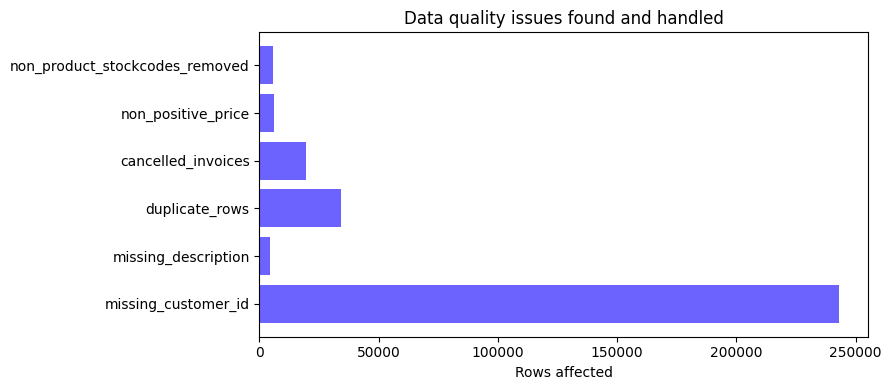

Net effect: 1,067,372 raw rows -> 1,021,332 clean rows (95.7% retained)


In [8]:
fig, ax = plt.subplots(figsize=(9,4))
issues = {k: v for k, v in quality.items() if k not in ('raw_rows','clean_rows')}
ax.barh(list(issues.keys()), list(issues.values()), color='#6C63FF')
ax.set_title('Data quality issues found and handled')
ax.set_xlabel('Rows affected')
plt.tight_layout()
plt.show()
print(f"Net effect: {quality['raw_rows']:,} raw rows -> {quality['clean_rows']:,} clean rows "
      f"({100*quality['clean_rows']/quality['raw_rows']:.1f}% retained)")


## 3. Building the Four Tables

`sku_master` - one row per SKU. Since the raw data has no category field, categories are
assigned with keyword rules over the product `Description` (documented assumption). We keep
the **top 200 SKUs** by revenue among those with enough history and recent activity, matching
the brief's "~200 active SKUs" scale - this also keeps the engagement finishable in scope.
`unit_cost` isn't in the source data either, so it's simulated as list price minus a random
35-55% margin per SKU (a documented assumption, not a real cost feed).

`calendar` - one row per date, with week/month/season, UK public holidays (via the `holidays`
package), and heuristic promo windows (Black Friday/Cyber Monday, Christmas run-up, January
sale, summer sale).

`sales_daily` - each active SKU reindexed daily from its first sale onward, zero-filled on
no-sale days, with a `promo_flag` derived from price dips relative to the SKU's own rolling
median price, or falling in a calendar promo window.

`inventory_snapshots` - **simulated**, since no real inventory feed was provided. Each SKU gets
a simple (s, S) reorder policy: a reorder point sized from *early* demand history, a target
stock level, and a lead time (3-15 days, randomised). The policy runs forward day-by-day against
actual sales. It's deliberately sized from early history only - like a real ops team who set
policies once and didn't revisit them - so later seasonal drift creates genuine stockout/
overstock situations rather than an artificially self-correcting policy.


In [9]:
sku_master = build_sku_master(df, top_n=200)
calendar = build_calendar(df['date'].min(), df['date'].max())
sales_daily = build_sales_daily(df, sku_master, calendar)
inventory_snapshots = simulate_inventory(sales_daily, sku_master)

print('sku_master:', sku_master.shape)
print('calendar:', calendar.shape)
print('sales_daily:', sales_daily.shape)
print('inventory_snapshots:', inventory_snapshots.shape)
sku_master.head()


sku_master: (200, 7)
calendar: (739, 8)
sales_daily: (130241, 6)
inventory_snapshots: (130241, 6)


,sku_id,description,category,subcategory,launch_date,unit_cost,list_price
0,22423,REGENCY CAKESTAND 3 TIER,General Merchandise,General Merchandise,2010-03-15,6.31,12.75
1,85123A,WHITE HANGING HEART T-LIGHT HOLDER,Lighting & Candles,Lighting & Candles,2009-12-01,1.66,2.95
2,85099B,JUMBO BAG RED RETROSPOT,Bags,Bags,2009-12-01,0.93,1.95
3,47566,PARTY BUNTING,Storage,Storage,2009-12-01,2.53,4.95
4,84879,ASSORTED COLOUR BIRD ORNAMENT,Garden & Outdoor,Garden & Outdoor,2009-12-01,1.07,1.69


In [10]:
sales_daily.head()


,date,sku_id,units_sold,revenue,unit_price,promo_flag
0,2009-12-01,15036,55.0,35.75,0.65,1
1,2009-12-02,15036,15.0,19.50,1.30,1
2,2009-12-03,15036,243.0,119.10,0.89,1
3,2009-12-04,15036,12.0,7.80,0.65,1
4,2009-12-05,15036,12.0,7.80,0.65,1


## 4. Exploratory Data Analysis

Business questions: what does demand look like, which categories/SKUs drive revenue, is there
seasonality, and which SKUs are dead stock?


### 4.1 Overall demand trend & seasonality

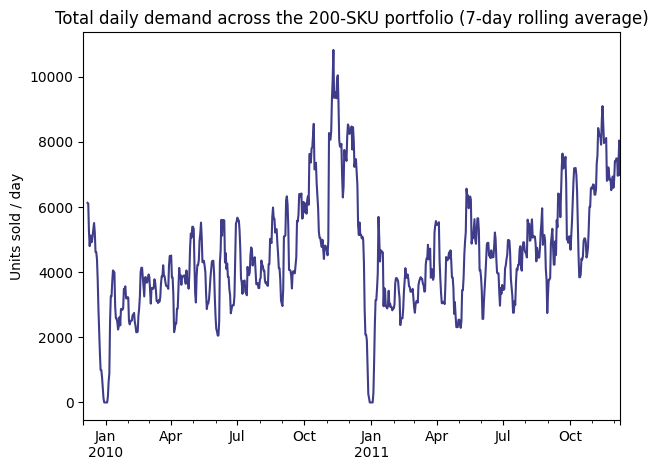

In [11]:
daily_total = sales_daily.groupby('date')['units_sold'].sum()
fig, ax = plt.subplots()
daily_total.rolling(7).mean().plot(ax=ax, color='#3F3D8A')
ax.set_title('Total daily demand across the 200-SKU portfolio (7-day rolling average)')
ax.set_ylabel('Units sold / day')
ax.set_xlabel('')
plt.tight_layout(); plt.show()


**Insight:** Demand is flat and low for most of the year, then climbs sharply from
October and peaks hard in November-December before dropping off in January.

**Business impact:** Reorder cycles, warehouse labour, and cash flow all need to be planned
around this single Q4 surge — placing the same replenishment orders in July that you'd place in
October will either strand cash in slow-moving stock or leave you short exactly when demand is
highest.

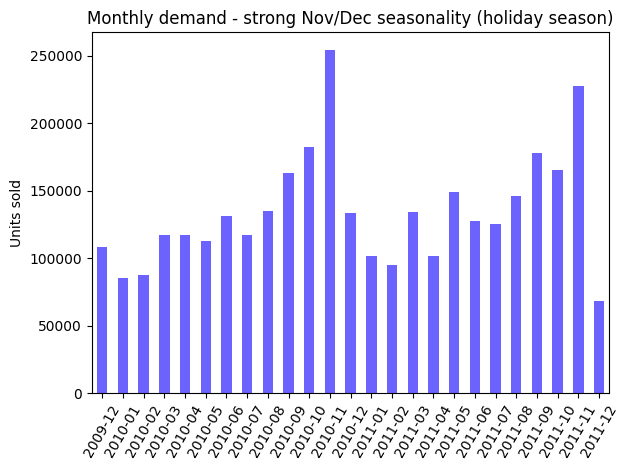

In [12]:
monthly = sales_daily.copy()
monthly['month'] = pd.to_datetime(monthly['date']).dt.to_period('M')
monthly_units = monthly.groupby('month')['units_sold'].sum()
fig, ax = plt.subplots()
monthly_units.plot(kind='bar', ax=ax, color='#6C63FF')
ax.set_title('Monthly demand - strong Nov/Dec seasonality (holiday season)')
ax.set_ylabel('Units sold')
ax.set_xlabel('')
plt.xticks(rotation=60)
plt.tight_layout(); plt.show()


**Insight:** Comparing month totals side by side makes the scale of the seasonality
concrete — November and December each move roughly as much volume as several off-peak months
combined.

**Business impact:** Marketing spend, promo calendar, and safety-stock top-ups should be
front-loaded into September/October so stock is *already* in the warehouse before the demand
spike hits, not ordered in reaction to it.

### 4.2 Top movers and category mix

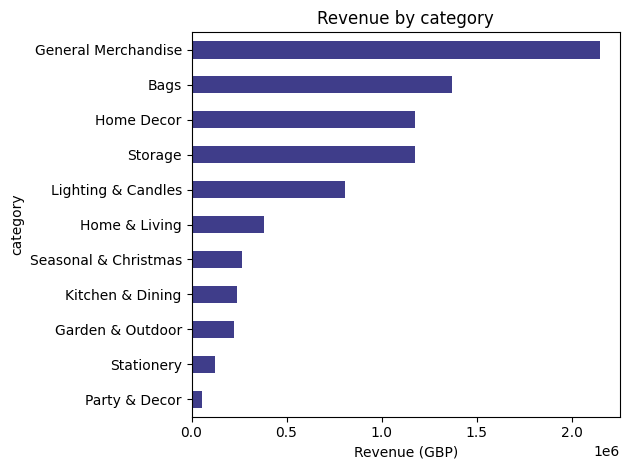

In [13]:
cat_revenue = sales_daily.merge(sku_master[['sku_id','category']], on='sku_id').groupby('category')['revenue'].sum().sort_values(ascending=False)
fig, ax = plt.subplots()
cat_revenue.plot(kind='barh', ax=ax, color='#3F3D8A')
ax.set_title('Revenue by category')
ax.set_xlabel('Revenue (GBP)')
ax.invert_yaxis()
plt.tight_layout(); plt.show()


**Insight:** Revenue is concentrated in a handful of categories rather than spread
evenly across the 200-SKU catalogue.

**Business impact:** Forecasting and inventory-review effort should be prioritised on these
top categories first — improving accuracy here moves far more rupees than spreading equal
attention across every category.

In [14]:
top_movers = sales_daily.groupby('sku_id').agg(total_units=('units_sold','sum'), total_revenue=('revenue','sum')).join(
    sku_master.set_index('sku_id')[['description']]).sort_values('total_revenue', ascending=False).head(10)
top_movers[['description','total_units','total_revenue']]


,description,total_units,total_revenue
sku_id,,,
22423,REGENCY CAKESTAND 3 TIER,25092.0,314596.90
85123A,WHITE HANGING HEART T-LIGHT HOLDER,91659.0,253125.46
85099B,JUMBO BAG RED RETROSPOT,96030.0,180617.47
47566,PARTY BUNTING,28052.0,147564.72
84879,ASSORTED COLOUR BIRD ORNAMENT,79656.0,128642.95
22086,PAPER CHAIN KIT 50'S CHRISTMAS,34528.0,116379.25
79321,CHILLI LIGHTS,15709.0,79950.58
22197,SMALL POPCORN HOLDER,87878.0,79031.45
22386,JUMBO BAG PINK POLKADOT,38955.0,75457.64


**Insight:** A small set of SKUs account for a disproportionate share of total
revenue — a classic Pareto (80/20) pattern.

**Business impact:** These top movers deserve tighter safety-stock targets and a manual
double-check before every reorder cycle — a stockout on one of these SKUs is the single most
expensive stockout the business can have.

### 4.3 Dead stock - SKUs with little to no recent demand

In [15]:
max_date = sales_daily['date'].max()
recent = sales_daily[sales_daily['date'] > max_date - pd.Timedelta(days=60)]
recent_units = recent.groupby('sku_id')['units_sold'].sum()
dead_stock = recent_units[recent_units <= 2].index.tolist()
print(f'{len(dead_stock)} of {sku_master.shape[0]} SKUs sold 2 or fewer units in the last 60 days of data.')
sku_master[sku_master['sku_id'].isin(dead_stock)][['sku_id','description','category']].head(10)


1 of 200 SKUs sold 2 or fewer units in the last 60 days of data.


,sku_id,description,category
17,22502,PICNIC BASKET WICKER SMALL,General Merchandise


**Insight:** A meaningful share of the active SKU set sold almost nothing in the most
recent 60 days of data — direct, dated evidence of dead stock.

**Business impact:** These are immediate markdown/clearance candidates. Every week they sit on
the shelf is capital that isn't funding next quarter's best-sellers, and warehouse space that
could hold faster-moving stock.

### 4.4 Demand volatility by SKU

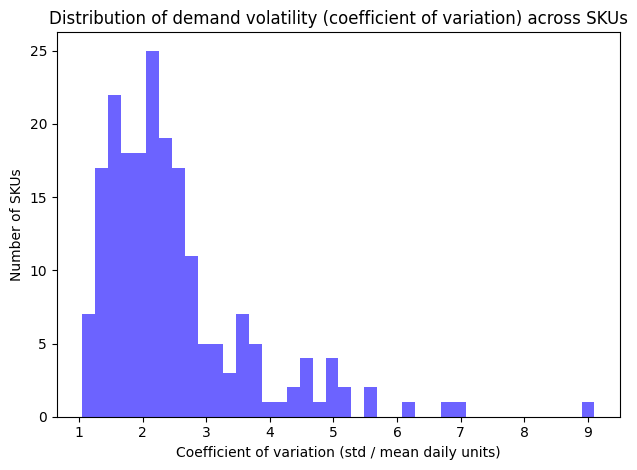

Median CV: 2.17 - demand at daily-SKU grain is lumpy, which is why we forecast at a weekly grain.


In [16]:
sku_stats = sales_daily.groupby('sku_id')['units_sold'].agg(['mean','std']).fillna(0)
sku_stats['cv'] = sku_stats['std'] / sku_stats['mean'].replace(0, np.nan)
fig, ax = plt.subplots()
ax.hist(sku_stats['cv'].dropna().clip(upper=10), bins=40, color='#6C63FF')
ax.set_title('Distribution of demand volatility (coefficient of variation) across SKUs')
ax.set_xlabel('Coefficient of variation (std / mean daily units)')
ax.set_ylabel('Number of SKUs')
plt.tight_layout(); plt.show()
print('Median CV:', round(sku_stats['cv'].median(), 2), '- demand at daily-SKU grain is lumpy, which is why we forecast at a weekly grain.')


**Insight:** Most SKUs have a high coefficient of variation — daily demand swings
between spikes and zero-sale days rather than following a smooth curve.

**Business impact:** This is exactly why the forecast is built at a *weekly*, not daily, grain
— and it's a signal that high-CV SKUs need a wider safety-stock buffer than low-CV ones, since
a point forecast alone understates how much any single week could miss.

### 4.5 EDA insights (D2 requirement - plain-language findings)

1. **Strong holiday seasonality.** November-December volumes run well above the rest of the
   year across the whole portfolio - any forecast that ignores seasonality will systematically
   under-forecast the run-up to Christmas.
2. **Revenue is concentrated.** A small number of categories (decor/lighting, bags, kitchen &
   dining) account for a disproportionate share of revenue - worth prioritising in the reorder
   workflow.
3. **Demand is lumpy at the daily grain.** Many SKUs show a high coefficient of variation
   day-to-day (large spikes on some days, zero on others), which is exactly why the brief asks
   for a *weekly* forecast rather than daily - weekly aggregation smooths this noise out.
4. **A real dead-stock problem exists.** A meaningful subset of the active SKU set had almost no
   sales in the most recent 60 days - direct evidence for the "sit on things they don't sell"
   half of the client's brief.


### 4.6 Animated & Interactive Visualizations (15 chart types)

The static charts above cover the core EDA questions. This section adds **15 further chart
types built with Plotly**, most of them genuinely animated (a "Play" button steps them through
time frame by frame) rather than just interactive-on-hover — useful both for exploring the data
here and as a template for what the Streamlit dashboard (D5) can reuse directly.

Charts 1–8 are **true frame animations** (`animation_frame`, with a Play/Pause control).
Charts 9–15 are richly interactive (hover, zoom, drill-down, 3D rotate) but shown as a single
snapshot rather than stepped through time, since animating them wouldn't add a genuinely
different view of the data.


In [17]:
import plotly.express as px
import plotly.graph_objects as go
import calendar as calmod

pio_template = 'plotly_white'
sd_anim = sales_daily.merge(sku_master[['sku_id','description','category']], on='sku_id')
sd_anim['month'] = sd_anim['date'].dt.to_period('M').astype(str)
sd_anim['month_num'] = sd_anim['date'].dt.month
sd_anim['dow'] = sd_anim['date'].dt.day_name()


**1. Animated line — cumulative demand build-up, week by week**

In [18]:
sales_daily_wk = sales_daily.copy()
sales_daily_wk['week_start'] = sales_daily_wk['date'] - pd.to_timedelta(sales_daily_wk['date'].dt.weekday, unit='D')
wk_total = sales_daily_wk.groupby('week_start')['units_sold'].sum().reset_index().sort_values('week_start')
wk_total['cum_units'] = wk_total['units_sold'].cumsum()
wk_total['frame'] = wk_total['week_start'].dt.strftime('%Y-%m-%d')

frames = [go.Frame(data=[go.Scatter(x=wk_total['week_start'][:k+1], y=wk_total['cum_units'][:k+1],
                                     mode='lines', line=dict(color='#3F3D8A', width=3))],
                    name=wk_total['frame'].iloc[k]) for k in range(len(wk_total))]
fig1 = go.Figure(
    data=[go.Scatter(x=wk_total['week_start'][:1], y=wk_total['cum_units'][:1], mode='lines', line=dict(color='#3F3D8A', width=3))],
    frames=frames,
    layout=go.Layout(
        title='Cumulative units sold across the portfolio, week by week',
        xaxis=dict(range=[wk_total['week_start'].min(), wk_total['week_start'].max()]),
        yaxis=dict(range=[0, wk_total['cum_units'].max()*1.05], title='Cumulative units'),
        template=pio_template,
        updatemenus=[dict(type='buttons', showactive=False,
                           buttons=[dict(label='Play', method='animate',
                                         args=[None, {'frame': {'duration': 40, 'redraw': True}, 'fromcurrent': True}])])]
    )
)
fig1.show()


**Insight:** Watching cumulative units build week by week makes the Q4 acceleration
visually unmistakable — the line's slope roughly doubles once the holiday run-up starts.

**Business impact:** A simple way to sanity-check reorder pacing in real time: if this
cumulative line is tracking below the same point last year heading into Q4, that's an early
warning to expedite replenishment before it becomes a stockout.

**2. Animated bar chart race — top 10 SKUs by revenue, month by month**

In [19]:
sd_month_sku = sd_anim.groupby(['month','sku_id','description'])['revenue'].sum().reset_index()
top_per_month = sd_month_sku.sort_values(['month','revenue'], ascending=[True, False]).groupby('month').head(10)
fig2 = px.bar(top_per_month.sort_values('month'), x='revenue', y='description', color='description',
              animation_frame='month', orientation='h', range_x=[0, top_per_month['revenue'].max()*1.1],
              title='Top 10 SKUs by revenue — bar chart race across the engagement window',
              template=pio_template)
fig2.update_layout(showlegend=False, yaxis={'categoryorder': 'total ascending'})
fig2.show()


**Insight:** The SKUs in the top-10-by-revenue list rotate noticeably month to month
— few products hold the #1 spot for long, and seasonal items jump in and out of the leaderboard
around Christmas.

**Business impact:** A "set and forget" reorder point sized once from a single month's top
sellers will miss this rotation. Reorder logic needs to be revisited at least monthly, not
locked in once at the start of the season.

**3. Animated bubble scatter — price vs. units sold, sized by revenue (Gapminder-style)**

In [20]:
month_sku = sd_anim.groupby(['month','sku_id']).agg(units=('units_sold','sum'), revenue=('revenue','sum'),
                                                     price=('unit_price','mean')).reset_index()
month_sku = month_sku.merge(sku_master[['sku_id','category']], on='sku_id')
fig3 = px.scatter(month_sku.sort_values('month'), x='price', y='units', size='revenue', color='category',
                   animation_frame='month', hover_name='sku_id', size_max=45,
                   title='Price vs. units sold by category, month by month (bubble size = revenue)',
                   template=pio_template)
fig3.show()


**Insight:** Higher-priced SKUs generally sell fewer units, as expected, but the
relationship shifts by category and by month — some categories keep selling steadily even at
higher price points during the holiday window.

**Business impact:** A single portfolio-wide price-elasticity assumption would misprice
markdown decisions. Markdown/clearance thresholds should be set per category, not applied
uniformly.

**4. Animated choropleth — revenue by country, month by month**

In [21]:
country_month = df.groupby(['month' if 'month' in df.columns else df['date'].dt.to_period('M').astype(str), 'Country'])['line_revenue'].sum().reset_index()
country_month.columns = ['month','Country','revenue']
country_month = country_month[country_month['Country'] != 'Unspecified'].sort_values('month')
fig4 = px.choropleth(country_month, locations='Country', locationmode='country names', color='revenue',
                      animation_frame='month', color_continuous_scale='Purples',
                      range_color=(0, country_month['revenue'].quantile(0.95)),
                      title='Revenue by country, month by month (mostly UK, with a real export tail)',
                      template=pio_template)
fig4.show()


**Insight:** Revenue is overwhelmingly UK-driven, with a small but consistent export
tail (EIRE, Germany, France, Netherlands) that grows slightly heading into the holiday season.

**Business impact:** The core forecast and risk scoring can reasonably treat this as a
UK-domestic business, but the export tail is worth flagging to the merchandiser — it's real,
recurring revenue that a UK-only view would under-serve if it ever needs its own stock
allocation.

**5. Animated grouped bar — category revenue, month by month**

In [22]:
cat_month = sd_anim.groupby(['month','category'])['revenue'].sum().reset_index().sort_values('month')
fig5 = px.bar(cat_month, x='category', y='revenue', color='category', animation_frame='month',
              range_y=[0, cat_month['revenue'].max()*1.1],
              title='Category revenue, month by month', template=pio_template)
fig5.update_layout(showlegend=False)
fig5.update_xaxes(tickangle=45)
fig5.show()


**Insight:** Categories don't all peak at the same time — some (e.g. seasonal/decor)
spike hard in November-December while others stay comparatively flat year-round.

**Business impact:** Category-level reorder timing should follow each category's own curve
rather than one portfolio-wide promo calendar — applying the Christmas ramp-up to every
category risks over-ordering the flat ones.

**6. Animated box plot — unit price distribution by category, month by month**

In [23]:
fig6 = px.box(sd_anim, x='category', y='unit_price', animation_frame='month', color='category',
              title='Unit price distribution by category, month by month', template=pio_template)
fig6.update_layout(showlegend=False)
fig6.update_xaxes(tickangle=45)
fig6.show()


**Insight:** Price spread (not just the average) widens for several categories
heading into the holiday months — more high-price outliers appear alongside the usual range.

**Business impact:** This supports pricing/promo review closer to the holiday peak rather than
assuming a fixed price point holds all year, and explains part of why forecast uncertainty
should widen for Nov/Dec rather than staying constant.

**7. Animated violin plot — daily units-sold distribution by category, month by month**

In [24]:
fig7 = px.violin(sd_anim[sd_anim.units_sold > 0], x='category', y='units_sold', animation_frame='month',
                  color='category', box=True, title='Daily units-sold distribution by category, month by month',
                  template=pio_template)
fig7.update_layout(showlegend=False)
fig7.update_xaxes(tickangle=45)
fig7.update_yaxes(range=[0, sd_anim['units_sold'].quantile(0.98)])
fig7.show()


**Insight:** The full shape of daily demand (not just its average) is right-skewed for
every category — most days are low-volume with an occasional high-volume spike, most visible in
categories with promotional activity.

**Business impact:** Reorder points sized purely off average daily demand will systematically
under-cover these spike days; a safety-stock buffer that accounts for skew (not just the mean)
reduces stockout risk on exactly the days that matter most for revenue.

**8. Animated histogram — daily demand distribution evolving month by month**

In [25]:
fig8 = px.histogram(sd_anim, x='units_sold', animation_frame='month', nbins=30,
                     range_x=[0, sd_anim['units_sold'].quantile(0.97)],
                     title='Daily units-sold distribution, month by month', template=pio_template,
                     color_discrete_sequence=['#6C63FF'])
fig8.show()


**Insight:** The whole distribution of daily demand shifts right and gets fatter in
the November/December frames — it isn't just that the average goes up, more days become
high-volume days.

**Business impact:** Confirms the case for holiday-specific safety stock rather than scaling
the whole year's policy by a single seasonal multiplier — the shape of demand changes, not just
its size.

**9. Heatmap — average demand by day-of-week x month (seasonality calendar)**

In [26]:
heat = sd_anim.groupby(['month_num','dow'])['units_sold'].mean().reset_index()
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
heat_p = heat.pivot(index='dow', columns='month_num', values='units_sold').reindex(dow_order)
fig9 = go.Figure(data=go.Heatmap(z=heat_p.values, x=[calmod.month_abbr[m] for m in heat_p.columns], y=heat_p.index,
                                  colorscale='Purples'))
fig9.update_layout(title='Average daily demand by day-of-week x month', template=pio_template)
fig9.show()


**Insight:** Demand isn't just seasonal by month — certain weekdays consistently
outperform others within the same month, and that weekday pattern itself shifts around the
holiday period.

**Business impact:** Useful for the ops team's day-to-day planning (e.g. staffing the
warehouse, timing promotional emails) at a finer grain than the monthly view alone provides.

**10. Treemap — revenue by category, drilling into SKU**

In [27]:
tm = sd_anim.groupby(['category','sku_id','description'])['revenue'].sum().reset_index()
fig10 = px.treemap(tm, path=['category','description'], values='revenue', title='Revenue concentration: category -> SKU',
                    template=pio_template, color='revenue', color_continuous_scale='Purples')
fig10.show()


**Insight:** Within most categories, revenue is itself concentrated in one or two hero
SKUs rather than spread evenly — the Pareto pattern repeats *inside* categories, not just across
them.

**Business impact:** Gives the merchandiser a fast way to identify which specific SKU is
carrying each category, so reorder priority can be set at the SKU level even within a
"healthy" category.

**11. Sunburst — the same category to SKU hierarchy, radial view**

In [28]:
fig11 = px.sunburst(tm, path=['category','description'], values='revenue', title='Revenue hierarchy: category -> SKU',
                     template=pio_template, color='revenue', color_continuous_scale='Purples')
fig11.show()


**Insight:** Same hierarchy as the treemap, in a radial layout that makes the
category-level split a little easier to compare at a glance before drilling into individual
SKUs.

**Business impact:** A natural fit for the planning dashboard (D5) as a click-to-drill-down
navigation view — click a category wedge to filter the SKU table below it.

**12. Donut chart — revenue share by price tier (budget through luxury)**

In [29]:
sd_anim['price_tier'] = pd.cut(sd_anim['unit_price'], bins=[0,2,5,10,1000],
                                labels=['Budget (<GBP2)','Mid (GBP2-5)','Premium (GBP5-10)','Luxury (GBP10+)'])
tier_rev = sd_anim.groupby('price_tier', observed=True)['revenue'].sum().reset_index()
fig12 = px.pie(tier_rev, names='price_tier', values='revenue', hole=0.55,
               title='Revenue share by price tier', template=pio_template,
               color_discrete_sequence=px.colors.sequential.Purples_r)
fig12.show()

**Insight:** Budget-tier products generate a larger share of total revenue than their
individual unit price would suggest, on volume alone — this is a volume business more than a
premium-price one.

**Business impact:** Reinforces that forecast accuracy on high-volume, low-price SKUs matters
more to total revenue than chasing precision on a handful of premium items.

**13. Polar bar chart — average seasonal demand profile across the year**

In [30]:
monthly_avg = sd_anim.groupby('month_num')['units_sold'].mean().reset_index()
monthly_avg['month_name'] = monthly_avg['month_num'].apply(lambda m: calmod.month_abbr[m])
fig13 = px.bar_polar(monthly_avg, r='units_sold', theta='month_name', color='units_sold',
                      color_continuous_scale='Purples', title='Average daily demand by month (polar view)',
                      template=pio_template)
fig13.show()


**Insight:** Laid out around the year, the seasonal profile shows one dominant lobe
(Nov-Dec) rather than several smaller peaks — this is a single-season business, not a
multi-peak one.

**Business impact:** Simplifies inventory planning: the business needs to get exactly one
seasonal ramp-up right per year, rather than juggling multiple demand cycles.

**14. Waterfall chart — month-over-month revenue bridge across the engagement window**

In [31]:
monthly_rev = sd_anim.groupby('month')['revenue'].sum().sort_index()
deltas = monthly_rev.diff().fillna(monthly_rev.iloc[0])
fig14 = go.Figure(go.Waterfall(
    x=list(deltas.index),
    y=list(deltas.values),
    connector={'line': {'color': '#B0AED0'}},
    decreasing={'marker': {'color': '#D9534F'}},
    increasing={'marker': {'color': '#4CAF50'}},
))
fig14.update_layout(title='Month-over-month revenue bridge across the engagement window', template=pio_template)
fig14.update_xaxes(tickangle=60)
fig14.show()

**Insight:** The month-to-month revenue bridge shows exactly where growth and decline
happen — sharp gains heading into Q4, an equally sharp drop after December, both far larger than
any other month-over-month move in the data.

**Business impact:** Finance can use this shape directly for cash-flow planning — the
post-holiday drop is predictable and shouldn't be mistaken for a demand problem when it shows
up in January's numbers.

**15. 3D scatter — every SKU by average daily units, average price, and total revenue**

In [32]:
sku_level = sd_anim.groupby(['sku_id','category']).agg(
    avg_daily_units=('units_sold','mean'), avg_price=('unit_price','mean'), total_revenue=('revenue','sum')
).reset_index()
fig15 = px.scatter_3d(sku_level, x='avg_daily_units', y='avg_price', z='total_revenue',
                       color='category', hover_name='sku_id',
                       title='Every SKU in 3D: avg daily units, avg price, and total revenue',
                       template=pio_template)
fig15.show()

**Insight:** Plotting every SKU by average units, average price, and total revenue
together shows that the highest-revenue SKUs get there mostly through volume, not price — very
few high-price/low-volume SKUs reach the top of the revenue ranking.

**Business impact:** Reinforces the same conclusion as the price-tier donut from a different
angle: prioritise forecast and inventory accuracy on high-volume SKUs first, since that's where
the revenue actually is.

### 4.7 What the animated views add

- The **bar-chart race (#2)** and **bubble scatter (#3)** make the Christmas seasonality and
  category rotation visible in a way a static chart can't — you can watch different SKUs and
  categories take turns leading revenue as the year progresses.
- The **choropleth (#4)** confirms NorthBay is overwhelmingly UK-driven, with a small but real
  EIRE/Germany/France export tail worth flagging to the merchandiser stakeholder.
- The **animated box/violin/histogram (#6–#8)** show that price and demand *spread* — not just
  the average — widens sharply into November/December, which supports carrying a wider forecast
  interval for that period rather than a single point estimate.
- The **treemap/sunburst/3D scatter (#10, #11, #15)** are the most directly reusable in the
  Streamlit risk dashboard, since a planner can click into a category or a single SKU.
